# 19 — End-to-End Loan Trace and Controls

## Following the calculation back to one loan

The final notebook follows one loan from raw contract fields through Standardised Approach and IRB, then reconciles all loan-level amounts with portfolio summaries.

Traceability and reconciliations do not create capital. They provide evidence that reported RWA and capital ratios are supported by the underlying loan calculations.

### How the final checks are described

| Term | Simple meaning |
|---|---|
| Calculation trace | ordered inputs, rules, intermediate values and outputs for one loan |
| Reconciliation | comparison of independently aggregated totals |
| Tolerance | a very small accepted numerical difference |
| Control status | PASS when the difference is within tolerance |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


## One loan from contract to both RWA approaches

The selected revolving loan shows the chronological path: class, CCF, EAD, risk weight, SA RWA, PD, downturn LGD, IRB EAD, maturity, correlation, conditional PD, K and IRB RWA.

In [2]:
trace_columns = [
    "exposure_id", "borrower_id", "product_type", "commitment_type", "performing_exposure_class", "classification_rule_id",
    "outstanding_balance", "accrued_interest", "undrawn_amount", "ccf", "converted_undrawn", "ead_pre_crm",
    "ltv", "sa_risk_weight", "sa_rule_id", "sa_rwa",
    "pd_transition_profile", "internal_grade", "pd_long_run", "pd_regulatory",
    "normal_lgd", "downturn_lgd", "lgd_regulatory", "irb_ccf", "ead_irb", "m_effective",
    "asset_correlation_r", "conditional_pd_999", "maturity_adjustment", "capital_k", "expected_loss_amount", "irb_rwa",
]
amount_columns = ["outstanding_balance", "accrued_interest", "undrawn_amount", "converted_undrawn", "ead_pre_crm", "sa_rwa", "ead_irb", "expected_loss_amount", "irb_rwa"]
trace_filter = loans["undrawn_amount"].gt(0) & loans["default_flag"].eq(0) & loans["capital_k"].gt(0)
traced_loan = loans.loc[trace_filter, trace_columns].head(1).copy()
traced_loan[amount_columns] /= CRORE
traced_loan = traced_loan.rename(columns={column: f"{column} (INR crore)" for column in amount_columns})
display(traced_loan.T.rename(columns={traced_loan.index[0]: "Value"}))

,Value
exposure_id,EXP-0009602
borrower_id,BOR-0009601
product_type,corporate_revolver
commitment_type,other_commitment
performing_exposure_class,corporate
classification_rule_id,CLASS_GENERAL_CORPORATE
outstanding_balance (INR crore),117.005903
accrued_interest (INR crore),0.338931
undrawn_amount (INR crore),35.013456
ccf,0.400000


## The selected loan in four monetary measures

The bars reduce the long trace to four comparable amounts. EAD is the exposure base. SA RWA and IRB RWA are two different capital-weighted views of that base. Expected loss is shown separately because it is not RWA.

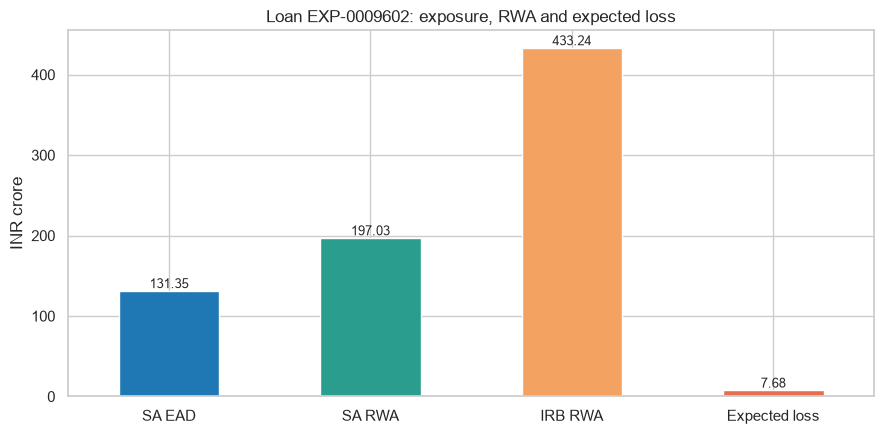

In [3]:
selected = loans.loc[trace_filter].iloc[0]
trace_amounts = pd.Series({
    "SA EAD": selected["ead_pre_crm"] / CRORE,
    "SA RWA": selected["sa_rwa"] / CRORE,
    "IRB RWA": selected["irb_rwa"] / CRORE,
    "Expected loss": selected["expected_loss_amount"] / CRORE,
})
axis = trace_amounts.plot.bar(figsize=(9, 4.5), color=[COLORS[1], COLORS[2], COLORS[4], COLORS[5]], title=f"Loan {selected['exposure_id']}: exposure, RWA and expected loss")
axis.set_ylabel("INR crore")
axis.set_xlabel("")
axis.tick_params(axis="x", rotation=0)
for position, value in enumerate(trace_amounts):
    axis.text(position, value, f"{value:,.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

The comparison shows why the trace keeps all four measures. A large EAD does not mechanically produce the same SA and IRB RWA, because the approaches apply different risk logic. Expected loss remains a separate average-loss measure.

Every important output remains on the same loan row. A surprising RWA can therefore be followed back to a commitment type, rating grade, recovery assumption, maturity or regulatory rule rather than appearing only as a portfolio total.

## Final portfolio controls

The controls compare direct loan-level sums with saved exposure-class summaries and confirm the formula identities used by both approaches.

In [4]:
sa_summary = pd.read_csv(ROOT / "outputs/tables/sa_summary.csv")
irb_summary = pd.read_csv(ROOT / "outputs/tables/irb_summary.csv")

controls = pd.DataFrame({
    "Control": [
        "SA EAD formula", "SA loan sum to class summary",
        "IRB RWA formula", "IRB loan sum to class summary",
        "Downturn LGD not below normal LGD", "Maturity within one-to-five-year ordinary bounds",
    ],
    "Difference or failed rows": [
        (loans["ead_pre_crm"] - loans["funded_exposure"] - loans["ccf"] * loans["undrawn_amount"]).abs().max() / CRORE,
        (loans["sa_rwa"].sum() - sa_summary["sa_rwa"].sum()) / CRORE,
        (loans["irb_rwa"] - 12.5 * loans["capital_k"] * loans["ead_irb"]).abs().max() / CRORE,
        (loans["irb_rwa"].sum() - irb_summary["irb_rwa"].sum()) / CRORE,
        int((loans["downturn_lgd"] < loans["normal_lgd"]).sum()),
        int((~loans["m_effective"].between(1, 5)).sum()),
    ],
})
controls["Status"] = np.where(controls["Difference or failed rows"].abs() < 1e-8, "PASS", "FAIL")
display(controls)
assert controls["Status"].eq("PASS").all()

,Control,Difference or failed rows,Status
0,SA EAD formula,0.000000,PASS
1,SA loan sum to class summary,0.000000,PASS
2,IRB RWA formula,0.000000,PASS
3,IRB loan sum to class summary,0.000000,PASS
4,Downturn LGD not below normal LGD,0.000000,PASS
5,Maturity within one-to-five-year ordinary bounds,0.000000,PASS


All controls must pass before the portfolio totals are treated as internally complete. These checks validate arithmetic and aggregation; they do not replace supervisory approval or empirical model validation.

## Completed project boundary

The engine now contains Basel exposure-class references, a necessary-variable synthetic portfolio, loan-level Standardised Approach CCF/EAD/risk weights/RWA, synthetic long-run PD transitions, recovery-based downturn LGD, IRB EAD and maturity, Basel correlations, conditional PD, capital K, loan-level IRB RWA, the output floor, stress testing, capital adequacy and reconciliation controls.

It does not claim confidential bank data, a fitted production rating model, A-IRB supervisory approval or a jurisdiction-specific regulatory filing.

The calculation chain is complete and internally reconciled from individual synthetic loans to Standardised Approach Credit RWA, IRB Credit RWA and capital adequacy.